*   Name: Shivprasad A. Mahind
*   PRN: 123B1B266  
*   Batch: D3


In [ ]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression

In [ ]:
### --- 1. Load the Dataset ---
print("### 1. Loading and Inspecting the Dataset")
df = pd.read_csv('/CarPrice_Assignment.csv')
print("Initial Dataset Head:")
print(df.head())
print("\nInitial Dataset Info:")
print(df.info())

### 1. Loading and Inspecting the Dataset
Initial Dataset Head:
   car_ID  symboling                   CarName  ... citympg highwaympg    price
0       1          3        alfa-romero giulia  ...      21         27  13495.0
1       2          3       alfa-romero stelvio  ...      21         27  16500.0
2       3          1  alfa-romero Quadrifoglio  ...      19         26  16500.0
3       4          2               audi 100 ls  ...      24         30  13950.0
4       5          2                audi 100ls  ...      18         22  17450.0

[5 rows x 26 columns]

Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        

In [ ]:
### --- 2. EDA and Outlier Treatment ---
print("\n### 2. Exploratory Data Analysis (EDA) and Outlier Treatment")
# Check for missing values (already confirmed by .info(), but good practice)
print(f"Number of missing values:\n{df.isnull().sum().to_string()}")


### 2. Exploratory Data Analysis (EDA) and Outlier Treatment
Number of missing values:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0


In [ ]:
# Outlier Treatment for 'price' using IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
num_outliers = len(df) - len(df_no_outliers)
print(f"\nNumber of price outliers removed: {num_outliers}")


Number of price outliers removed: 15



### 3. Creating Visualizations
Visualizations saved to eda_plots_with_fs.png


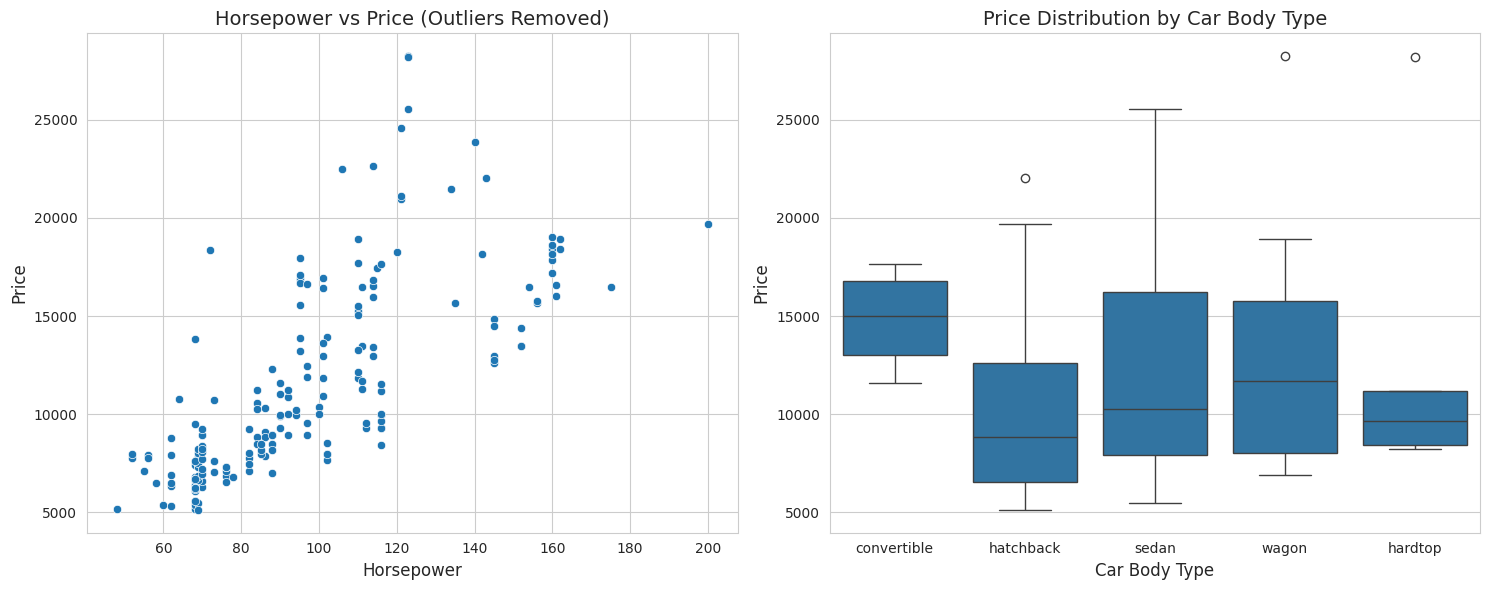

In [ ]:
### --- 3. Visualizations ---
print("\n### 3. Creating Visualizations")
sns.set_style("whitegrid")
plt.figure(figsize=(15, 6))

# Scatter plot of horsepower vs price
plt.subplot(1, 2, 1)
sns.scatterplot(x='horsepower', y='price', data=df_no_outliers)
plt.title('Horsepower vs Price (Outliers Removed)', fontsize=14)
plt.xlabel('Horsepower', fontsize=12)
plt.ylabel('Price', fontsize=12)

# Box plot of price by carbody
plt.subplot(1, 2, 2)
sns.boxplot(x='carbody', y='price', data=df_no_outliers)
plt.title('Price Distribution by Car Body Type', fontsize=14)
plt.xlabel('Car Body Type', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.tight_layout()
plt.savefig('eda_plots_with_fs.png')
print("Visualizations saved to eda_plots_with_fs.png")
plt.show()

# Use the cleaned data for further steps
df = df_no_outliers.copy()

# **Data Preprocessing**

*   Techniques & Purpose:

    *   Feature Engineering: A new feature, CarCompany, is created by extracting the brand name from the CarName column. This is useful because brand is a stronger predictor than a specific model name. The original CarName and irrelevant car_ID columns are then dropped.
    *   Categorical to Numerical Mapping: The doornumber and cylindernumber columns, which have text values like 'two' and 'four', are converted into numerical values (2, 4) using a dictionary map.
    *   One-Hot Encoding (pd.get_dummies): This technique converts categorical variables (like fueltype, carbody) into a numerical format. It creates new binary (0/1) columns for each category, indicating its presence or absence. This is essential because linear models can only work with numerical data.
    *   Train-Test Split: The data is split into a training set (80%) and a testing set (20%). The model learns the patterns from the training set, and its performance is evaluated on the unseen testing set to ensure it generalizes well.
    *   Feature Scaling (StandardScaler): This technique standardizes numerical features by subtracting the mean and dividing by the standard deviation. Purpose: It prevents features with large ranges (e.g., curbweight) from dominating features with smaller ranges (e.g., boreratio), which is crucial for regularization models like Ridge and Lasso whose penalty terms are sensitive to feature scales.

*   Insights: This comprehensive preprocessing step transforms the dataset into a fully numerical format. The number of features expands from the original count to 61 due to one-hot encoding. The data is now properly partitioned and scaled, ready for feature selection and modeling.



In [ ]:
### --- 4. Data Preprocessing ---
print("\n### 4. Data Preprocessing")
# Feature Engineering: Extract Car Company Name
df['CarCompany'] = df['CarName'].apply(lambda x: x.split(' ')[0])
df.drop('CarName', axis=1, inplace=True)
df.drop('car_ID', axis=1, inplace=True)

# Data Transformation: Convert text to numerical
doornumber_map = {'two': 2, 'four': 4}
df['doornumber'] = df['doornumber'].map(doornumber_map)

cylindernumber_map = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
df['cylindernumber'] = df['cylindernumber'].map(cylindernumber_map)

# One-hot Encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling Numerical Features
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Shape of X_train after preprocessing: {X_train.shape}")
print(f"Shape of X_test after preprocessing: {X_test.shape}")


### 4. Data Preprocessing
Shape of X_train after preprocessing: (152, 61)
Shape of X_test after preprocessing: (38, 61)


# **Feature Selection**

*   Technique & Purpose:

    *   SelectKBest with f_regression: This is a univariate feature selection method.
    *   Definition: It works by calculating a statistical score for each feature individually against the target variable (price). The f_regression score computes an F-statistic, which measures the strength of the linear relationship between a feature and the target. SelectKBest then selects the k features with the highest scores.
    *   Purpose: After one-hot encoding, we had 61 features. Using all of them could lead to overfitting (a model that performs well on training data but poorly on new data) and make the model harder to interpret. By selecting the top 30 features, we simplify the model, potentially improve its generalization, and focus on the most influential variables.

*   Insights: The output lists the 30 most predictive features, including curbweight, enginesize, horsepower, carwidth, and flags for drivewheel_rwd and specific companies like bmw and buick. This confirms that physical dimensions, engine power, and brand prestige are key drivers of car price.



In [ ]:
### --- 5. Feature Selection ---
print("\n### 5. Feature Selection using SelectKBest")
# Use SelectKBest to select the top 30 features based on f_regression score
selector = SelectKBest(score_func=f_regression, k=30)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print(f"Shape of X_train after feature selection: {X_train_selected.shape}")
print(f"Shape of X_test after feature selection: {X_test_selected.shape}")

# Get the selected feature names
selected_features_mask = selector.get_support()
selected_feature_names = X.columns[selected_features_mask]
print("\nSelected features:")
print(selected_feature_names.tolist())


### 5. Feature Selection using SelectKBest
Shape of X_train after feature selection: (152, 30)
Shape of X_test after feature selection: (38, 30)

Selected features:
['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'cylindernumber', 'enginesize', 'boreratio', 'compressionratio', 'horsepower', 'citympg', 'highwaympg', 'fueltype_gas', 'aspiration_turbo', 'carbody_hatchback', 'drivewheel_fwd', 'drivewheel_rwd', 'enginetype_l', 'enginetype_ohc', 'enginetype_ohcv', 'fuelsystem_2bbl', 'fuelsystem_idi', 'fuelsystem_mpfi', 'CarCompany_audi', 'CarCompany_bmw', 'CarCompany_buick', 'CarCompany_honda', 'CarCompany_peugeot', 'CarCompany_toyota', 'CarCompany_volvo']


# **Model Training and Evaluation**

*   Models & Purpose:

    *   Linear Regression: This is the baseline model. It finds the best-fitting straight line (or hyperplane) through the data by minimizing the sum of squared errors, but it's prone to overfitting when there are many features.
    *   Ridge Regression (L2 Regularization): This model adds a penalty based on the squared magnitude of the coefficients (L2 norm). Purpose: It shrinks the coefficients of less important features towards zero (but not exactly zero), which helps to reduce model complexity and prevent overfitting. The strength of this penalty is controlled by the hyperparameter alpha.
    *   Lasso Regression (L1 Regularization): This model adds a penalty based on the absolute magnitude of the coefficients (L1 norm). Purpose: Like Ridge, it combats overfitting. However, Lasso can shrink the coefficients of irrelevant features to exactly zero, effectively performing automatic feature selection.
    *   Elastic Net Regression: This is a hybrid model that combines both L1 (Lasso) and L2 (Ridge) penalties. Purpose: It gets the best of both worlds—it can perform feature selection like Lasso while handling correlated features more effectively, similar to Ridge.


*   Techniques:

    *   GridSearchCV: This technique is used to find the optimal alpha (and l1_ratio for Elastic Net) by trying out all combinations from a predefined grid of values and using cross-validation to see which combination performs best.
    *   Evaluation Metrics:

        *   R2(R-squared): Indicates the proportion of variance in the price that is explained by the model. A value of 0.82 means the model explains 82% of the price variability.
        *   RMSE (Root Mean Squared Error): Measures the average magnitude of the prediction errors in the same units as the target (dollars). An RMSE of 1724 means the model's predictions are, on average, off by about $1,724.

*   Insights:

    *   The baseline Linear Regression shows signs of overfitting, with a high training R2 (0.916) but a lower test R2 (0.821).
    *   The regularized models (Ridge and Elastic Net) close this gap, showing slightly lower training scores but better test scores.
    *   Elastic Net performed the best on the unseen test data, achieving the highest R2(0.823) and lowest RMSE ($1724.16). This suggests that its combined L1 and L2 penalty was most effective at creating a robust and generalizable model for this dataset.


In [ ]:
### --- 6. Model Training and Evaluation ---
print("\n### 6. Model Training and Evaluation")

# A helper function to evaluate and print model performance

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        'R^2 (Train)' : r2_score(y_train, y_train_pred),
        'R^2 (Test)': r2_score(y_test, y_test_pred),
        'MSE (Train)': mean_squared_error(y_train, y_train_pred),
        'MSE (Test)': mean_squared_error(y_test, y_test_pred),
        'RMSE (Train)': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE (Test)': np.sqrt(mean_squared_error(y_test, y_test_pred))
    }

    return metrics

results = {}

# 6.1. Linear Regression (Baseline Model)
print("--- 6.1. Linear Regression (Baseline) ---")

lr_model = LinearRegression()
results['LinearRegression'] = evaluate_model(lr_model, X_train_selected, y_train, X_test_selected, y_test)
for metric, value in results['LinearRegression'].items():
  print(f"{metric}: {value:.4f}")

# 6.2. Ridge Regression
print("\n--- 6.2. Ridge Regression ---")
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_selected, y_train)
results['Ridge Regression'] = evaluate_model(ridge_cv.best_estimator_, X_train_selected, y_train, X_test_selected, y_test)
print(f"  Best Alpha: {ridge_cv.best_params_['alpha']}")
for metric, value in results['Ridge Regression'].items():
    print(f"  {metric}: {value:.4f}")

# 6.3. Lasso Regression
print("\n--- 6.3. Lasso Regression ---")
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
lasso_cv = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train_selected, y_train)
results['Lasso Regression'] = evaluate_model(lasso_cv.best_estimator_, X_train_selected, y_train, X_test_selected, y_test)
print(f"  Best Alpha: {lasso_cv.best_params_['alpha']}")
for metric, value in results['Lasso Regression'].items():
    print(f"  {metric}: {value:.4f}")

# 6.4. Elastic Net Regression
print("\n--- 6.4. Elastic Net Regression ---")
elastic_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]
}
elastic_cv = GridSearchCV(ElasticNet(max_iter=10000), elastic_params, cv=5, scoring='neg_mean_squared_error')
elastic_cv.fit(X_train_selected, y_train)
results['Elastic Net Regression'] = evaluate_model(elastic_cv.best_estimator_, X_train_selected, y_train, X_test_selected, y_test)
print(f"  Best Alpha: {elastic_cv.best_params_['alpha']}")
print(f"  Best L1 Ratio: {elastic_cv.best_params_['l1_ratio']}")
for metric, value in results['Elastic Net Regression'].items():
    print(f"  {metric}: {value:.4f}")


### 6. Model Training and Evaluation
--- 6.1. Linear Regression (Baseline) ---
R^2 (Train): 0.9162
R^2 (Test): 0.8214
MSE (Train): 2132515.5293
MSE (Test): 3001768.4947
RMSE (Train): 1460.3135
RMSE (Test): 1732.5613

--- 6.2. Ridge Regression ---
  Best Alpha: 1
  R^2 (Train): 0.9098
  R^2 (Test): 0.8222
  MSE (Train): 2295487.5196
  MSE (Test): 2989562.7508
  RMSE (Train): 1515.0866
  RMSE (Test): 1729.0352

--- 6.3. Lasso Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.094e+07, tolerance: 3.420e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.610e+07, tolerance: 3.141e+05
  model = cd_fast.enet_coordinate_descent(


  Best Alpha: 10
  R^2 (Train): 0.9115
  R^2 (Test): 0.8206
  MSE (Train): 2252255.8802
  MSE (Test): 3015439.6243
  RMSE (Train): 1500.7518
  RMSE (Test): 1736.5021

--- 6.4. Elastic Net Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.463e+07, tolerance: 3.420e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.499e+07, tolerance: 3.141e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.757e+07, tolerance: 2.873e

  Best Alpha: 0.1
  Best L1 Ratio: 0.95
  R^2 (Train): 0.9117
  R^2 (Test): 0.8232
  MSE (Train): 2247101.2032
  MSE (Test): 2972731.2157
  RMSE (Train): 1499.0334
  RMSE (Test): 1724.1610


# **Final Model Comparison and Visualizations**

*   Techniques & Purpose:

    *   Comparison DataFrame: The results from all models are organized into a clean table. This allows for an easy and direct comparison of their performance metrics, making it clear which model is superior.
    *   Actual vs. Predicted Plots: These scatter plots compare the actual car prices from the test set against the prices predicted by each model. A perfect model would have all points lying on the diagonal red line (where Actual Price = Predicted Price).

*   Insights:

    *   The table confirms that Elastic Net is the winning model.
    *   The plots provide a visual confirmation of the models' accuracy. The points on the Elastic Net plot would appear most tightly clustered around the diagonal line, visually demonstrating its superior predictive power on new data.

In [ ]:
### --- 7. Final Model Comparison ---
print("\n### 7. Final Model Comparison Table")
comparison_df = pd.DataFrame(results).T
print(comparison_df[['R^2 (Train)', 'R^2 (Test)', 'RMSE (Train)', 'RMSE (Test)']].sort_values(by='R^2 (Test)', ascending=False))


### 7. Final Model Comparison Table
                        R^2 (Train)  R^2 (Test)  RMSE (Train)  RMSE (Test)
Elastic Net Regression     0.911664    0.823152   1499.033423  1724.161018
Ridge Regression           0.909762    0.822151   1515.086638  1729.035208
LinearRegression           0.916168    0.821425   1460.313504  1732.561253
Lasso Regression           0.911461    0.820611   1500.751772  1736.502123



### 8. Regression Visualizations (Actual vs. Predicted)
Regression visualizations saved to regression_predictions_plot.png


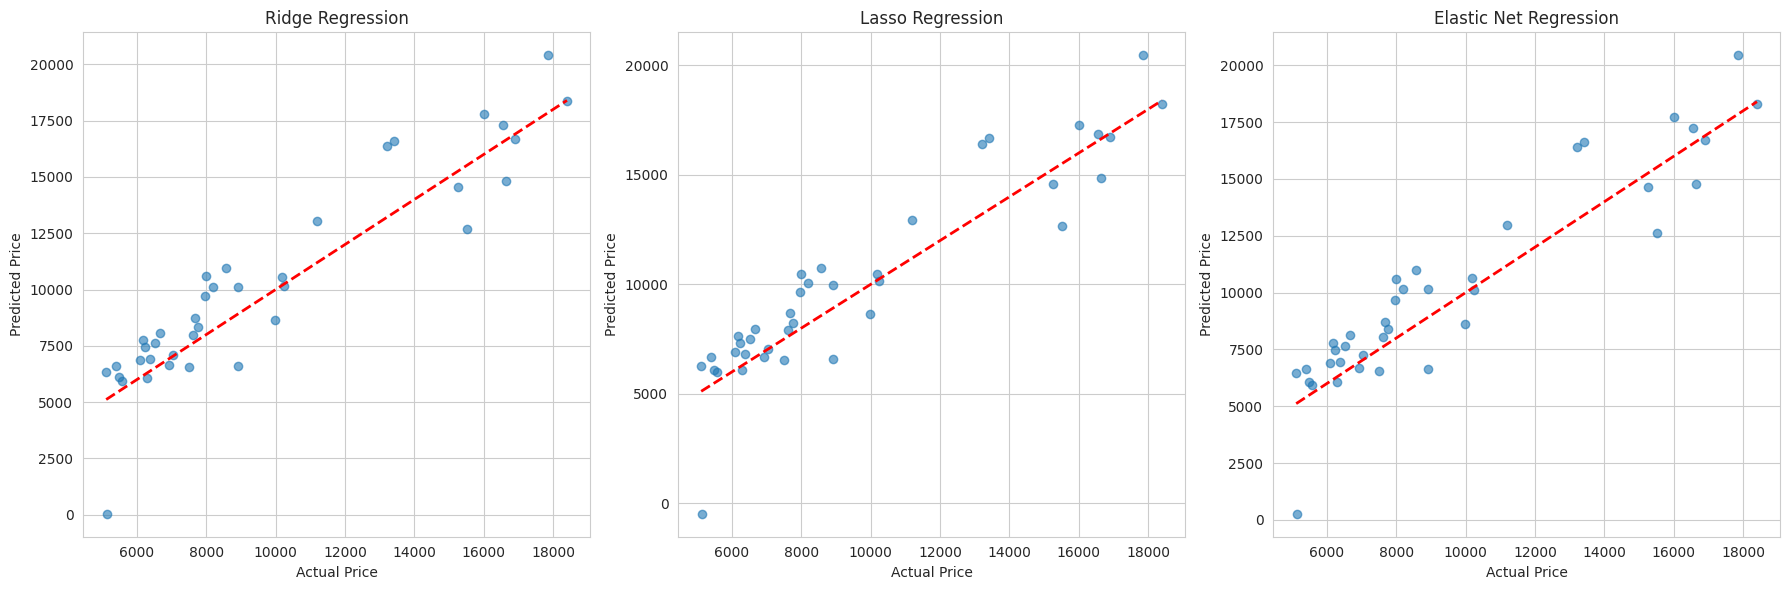

In [ ]:
### --- 8. Regression Visualizations ---
print("\n### 8. Regression Visualizations (Actual vs. Predicted)")

def plot_predictions(model, X_test, y_test, title, ax):
    """Plots actual vs. predicted values for a given model."""
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_title(title)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

plot_predictions(ridge_cv.best_estimator_, X_test_selected, y_test, 'Ridge Regression', axs[0])
plot_predictions(lasso_cv.best_estimator_, X_test_selected, y_test, 'Lasso Regression', axs[1])
plot_predictions(elastic_cv.best_estimator_, X_test_selected, y_test, 'Elastic Net Regression', axs[2])

plt.tight_layout()
plt.savefig('regression_predictions_plot.png')
print("Regression visualizations saved to regression_predictions_plot.png")
plt.show()

# **Observations**

1.   Data Exploration and Understanding:

  *   Dataset Overview: The assignment uses the Car Price dataset, which contains 205 records and 26 features, including the target variable price.
  *   Data Integrity: An initial check confirmed that the dataset was complete, with no missing or null values in any of the columns.
  *   Feature Types: The dataset comprises a mix of numerical features (price, horsepower, enginesize) and categorical features (fueltype, carbody, CarName).
  *   Initial Relationships: Exploratory visualizations provided key insights:

      *   The scatter plot of Horsepower vs. Price showed a clear positive correlation, suggesting that more powerful cars are generally more expensive.
      *   The box plot of Price by Car Body Type indicated that prices vary significantly across different categories, with types like 'convertible' and 'hardtop' showing higher median prices.

2.   Data Preprocessing and Feature Engineering:

*   Outlier Removal: The Interquartile Range (IQR) method was applied to the price column to handle extreme values. This crucial step removed 15 outliers, resulting in a cleaner dataset of 190 records for modeling.
*   Feature Engineering:

    *   The CarName feature was simplified by extracting the brand into a new CarCompany column, making it a more effective predictor.
    *   Text-based numerical features like doornumber and cylindernumber were mapped from words ('two', 'four') to integers (2, 4).


*   Categorical Data Encoding: Categorical features were converted into a numerical format using one-hot encoding (pd.get_dummies), which expanded the feature set to 61 predictors.
*   Feature Scaling: StandardScaler was applied to all numerical features. This step was essential to ensure that all features were on a comparable scale, which is critical for the performance of regularized regression models.


3. Feature Selection:

*   Methodology: The SelectKBest technique, using the f_regression score, was employed to reduce the number of features. This method selects features that have the strongest individual linear relationship with the target variable (price).
*   Impact: The feature set was successfully reduced from 61 to the top 30 most predictive variables, simplifying the model and reducing the risk of overfitting. Key predictors identified included enginesize, curbweight, horsepower, and drivewheel_rwd.

4. Model Training, Tuning, and Performance:

*   Model Selection: Four different linear models were trained and compared: a baseline LinearRegression model and three regularized models (Ridge, Lasso, and Elastic Net) to control for overfitting.
*   Hyperparameter Tuning: GridSearchCV was used to systematically find the optimal regularization strength (alpha) and L1/L2 mix (l1_ratio) for the regularized models, ensuring they were tuned for best performance.
*   Model Performance:

    *   The baseline LinearRegression model showed signs of slight overfitting, with a higher R² on the training set (0.916) than on the test set (0.821).
    *   All regularized models successfully reduced this overfitting and generalized better to the test data.
    *   Elastic Net Regression emerged as the best model, achieving the highest R-squared (R²) value of 0.823 on the test data.
    *   This indicates that the final model can explain approximately 82.3% of the variance in car prices.
    *   The Root Mean Squared Error (RMSE) for the Elastic Net model was $1,724.16, representing the typical error margin of its price predictions.

*   Prediction Visualization: The scatter plots comparing actual vs. predicted prices for the regularized models showed points clustering tightly around the ideal 45-degree line, visually confirming their strong predictive accuracy.





